In [2]:
import pandas as pd

In [3]:
dataset=pd.read_csv("Salary_dataset.csv")

In [4]:
dataset

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [5]:
dataset = dataset.drop(columns=['Unnamed: 0'])

In [6]:
dataset

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0
5,3.0,56643.0
6,3.1,60151.0
7,3.3,54446.0
8,3.3,64446.0
9,3.8,57190.0


In [7]:
dataset.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [8]:
x=dataset[["YearsExperience"]] 
y=dataset[["Salary"]]

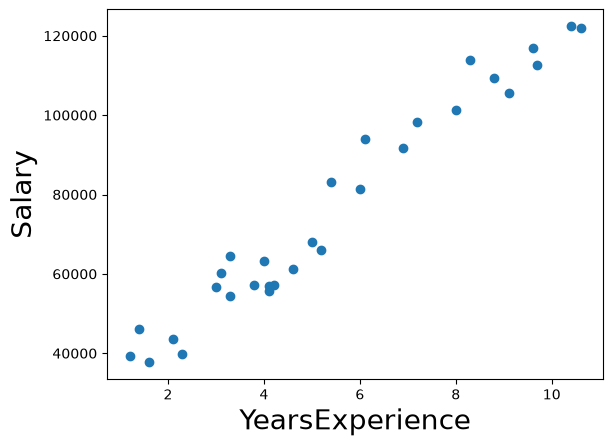

In [9]:
import matplotlib.pyplot as plt
plt.scatter(x,y) 
plt.xlabel('YearsExperience', fontsize=20) 
plt.ylabel('Salary', fontsize=20) 
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=11)

In [11]:
from sklearn.linear_model import LinearRegression 
regressor=LinearRegression() 
regressor.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[9504.98]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[24425.81]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [12]:
weight = regressor.coef_
print("Weight of the model={}".format(weight)) 
bais = regressor.intercept_
print("Intercept of the model={}".format(bais))

Weight of the model=[[9504.98248109]]
Intercept of the model=[24425.80702317]


In [13]:
y_pred=regressor.predict(x_test) 
y_pred

array([[ 71950.71942864],
       [ 55792.24921078],
       [ 53891.25271456],
       [115673.63884167],
       [ 44386.27023347],
       [ 63396.23519566]])

In [14]:
x_test

,YearsExperience
15,5.0
8,3.3
6,3.1
26,9.6
3,2.1
11,4.1


In [15]:
y_test

,Salary
15,67939.0
8,64446.0
6,60151.0
26,116970.0
3,43526.0
11,55795.0


In [16]:
y_pred

array([[ 71950.71942864],
       [ 55792.24921078],
       [ 53891.25271456],
       [115673.63884167],
       [ 44386.27023347],
       [ 63396.23519566]])

In [17]:
import pandas as pd 
results = pd.DataFrame({    
    'YearsExperience': x_test.iloc[:, 0].values,    
    'Actual_Salary': y_test.iloc[:, 0].values,    
    'Predicted_Salary': y_pred.flatten() 
}) 
print(results)

   YearsExperience  Actual_Salary  Predicted_Salary
0              5.0        67939.0      71950.719429
1              3.3        64446.0      55792.249211
2              3.1        60151.0      53891.252715
3              9.6       116970.0     115673.638842
4              2.1        43526.0      44386.270233
5              4.1        55795.0      63396.235196


In [18]:
from sklearn.metrics import r2_score 
ab=r2_score(y_test,y_pred)*100
ab

94.08827284776221

In [19]:
import pickle 
filename = 'finalized_model.sav' 
pickle.dump(regressor, open(filename, 'wb'))

In [20]:
loaded_model = pickle.load(open('finalized_model.sav', 'rb')) 
result = loaded_model.predict([[15]]) 
print(result)

[[167000.54423958]]


C:\Users\goushik lap\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [21]:
prediction_input = int(input("Enter the Prediction input value:")) 
if prediction_input > 60:
    print("Person doesn't exist anymore")
else:
    Future_Prediction = regressor.predict([[prediction_input]]) 
    print("Future_Prediction={}".format(Future_Prediction))

Enter the Prediction input value: 55


Future_Prediction=[[547199.84348331]]


C:\Users\goushik lap\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
